<a href="https://colab.research.google.com/github/misbahsaaeed-creator/Data-Analytics-Internship-CodeAlpha./blob/main/Smart_Agriculture_Project_(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Smart Agriculture Decision Support System
### Data Science Semester Project

---

## Problem Statement

In Pakistan, most farmers are uneducated and cannot visit labs for soil testing. They do not know which crop suits their soil, leading to poor productivity.

**Every region has different soil** — Multan soil is different from Lahore or Peshawar.

## Our Solution

A Smart System where the farmer:
- Selects their **city, soil color, and texture** (simple choices)
- OR **speaks** their query by voice
- Gets the **best crop recommendation** with image
- Hears the result in **Urdu + English voice**

**No lab test needed. No technical knowledge needed.**

---

## Dataset
- Source: Kaggle — Crop Recommendation Dataset by Atharva Ingle
- Rows: 2200 | Columns: 8 | Crops: 22
- Features: N, P, K, temperature, humidity, pH, rainfall → label (crop)

---

## Step 1: Install and Import Libraries

### Why each library?
| Library | Purpose |
|---|---|
| `pandas` | Read CSV, handle data like Excel |
| `numpy` | Fast math operations for ML |
| `matplotlib` | Draw basic graphs |
| `seaborn` | Beautiful graphs (heatmap, boxplot) |
| `sklearn` | All ML algorithms (Decision Tree, Random Forest, KNN) |
| `gTTS` | Convert text to voice (Google Text-to-Speech) |
| `gradio` | Build web UI with dropdowns, buttons, images |
| `requests` | Download crop images from internet |
| `SpeechRecognition` | Convert farmer's voice to text |

In [4]:
# Install libraries not available by default
!pip install gradio gtts SpeechRecognition -q

# Data handling
import pandas as pd          # pd = short nickname for pandas
import numpy as np            # np = short nickname for numpy

# Visualization
import matplotlib.pyplot as plt   # plt = draw graphs
import seaborn as sns             # sns = beautiful graphs

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier       # Model 1
from sklearn.ensemble import RandomForestClassifier, VotingClassifier  # Model 2 + Fusion
from sklearn.neighbors import KNeighborsClassifier    # Model 3
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Voice
from gtts import gTTS
from IPython.display import Audio, display

# UI
import gradio as gr

# Utilities
import requests, os, warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [5]:
import os

# First download dataset again
import kagglehub
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

# Now load it
csv_file = os.path.join(path, 'Crop_recommendation.csv')
df = pd.read_csv(csv_file)

print('✅ Dataset loaded!')
print(f'   Total rows    : {df.shape[0]}')
print(f'   Total columns : {df.shape[1]}')
print(f'   Total crops   : {df["label"].nunique()}')
df.head()

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
✅ Dataset loaded!
   Total rows    : 2200
   Total columns : 8
   Total crops   : 22


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Step 2: Load the Dataset

### What is a Dataset?
Think of it like an Excel sheet with 2200 rows.
Each row = one soil sample with its best crop.

### Train vs Test Split
- **Train (80%)** = Model learns from this — like studying before exam
- **Test (20%)** = We check model on this — like the actual exam


In [6]:
# Basic info about dataset
print('=== Column Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Statistical Summary ===')
df.describe()

=== Column Data Types ===
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

=== Missing Values ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Statistical Summary ===


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## Step 3: Exploratory Data Analysis (EDA)

### What is EDA?
Before training a model, we **explore** the data visually.
EDA answers questions like:
- Is the data balanced?
- What are the value ranges?
- Are any features related to each other?

### Graphs We Will Make:
| Graph | Type | Why |
|---|---|---|
| Crop Count | Bar Chart | Are all crops equally present? |
| Value Ranges | Histogram | How are N,P,K values spread? |
| Relationships | Heatmap | Are any features correlated? |
| NPK per Crop | Grouped Bar | Which crop needs what soil? |
| pH per Crop | Boxplot | pH range for each crop? |

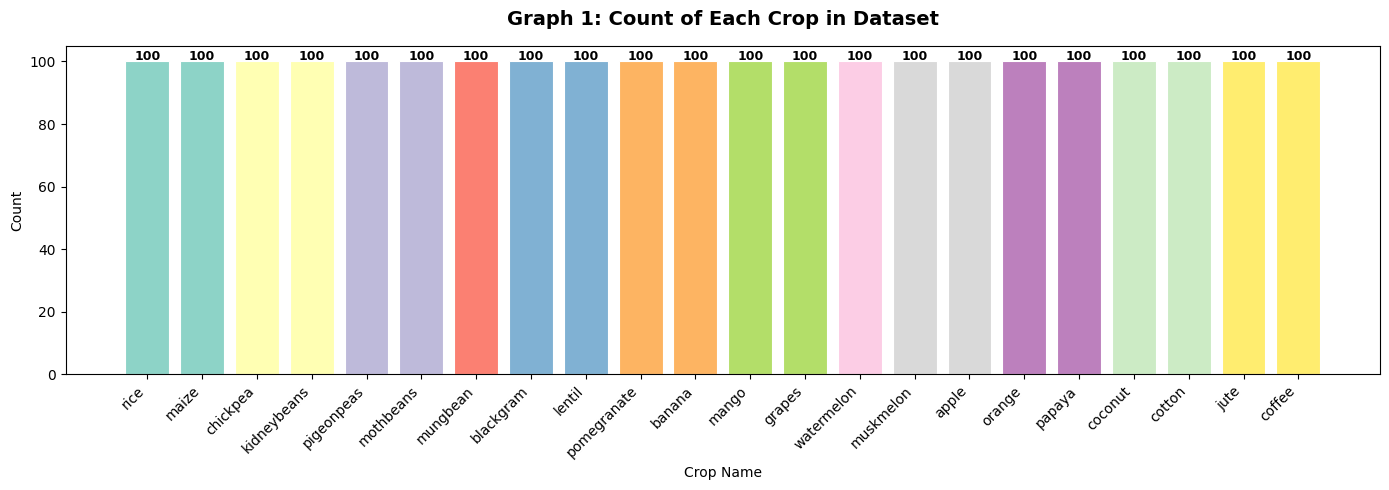

Observation: Each crop has exactly 100 samples — perfectly balanced dataset!


In [7]:
# ── GRAPH 1: BAR CHART — Crop Count ──────────────────
# Bar Chart: Used to compare quantities of different categories
# Why here: Check if all 22 crops have equal data (balanced dataset)

plt.figure(figsize=(14, 5))
counts = df['label'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(counts)))

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)

# Add count number on top of each bar
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontsize=9, fontweight='bold')

plt.title('Graph 1: Count of Each Crop in Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Crop Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Observation: Each crop has exactly 100 samples — perfectly balanced dataset!')

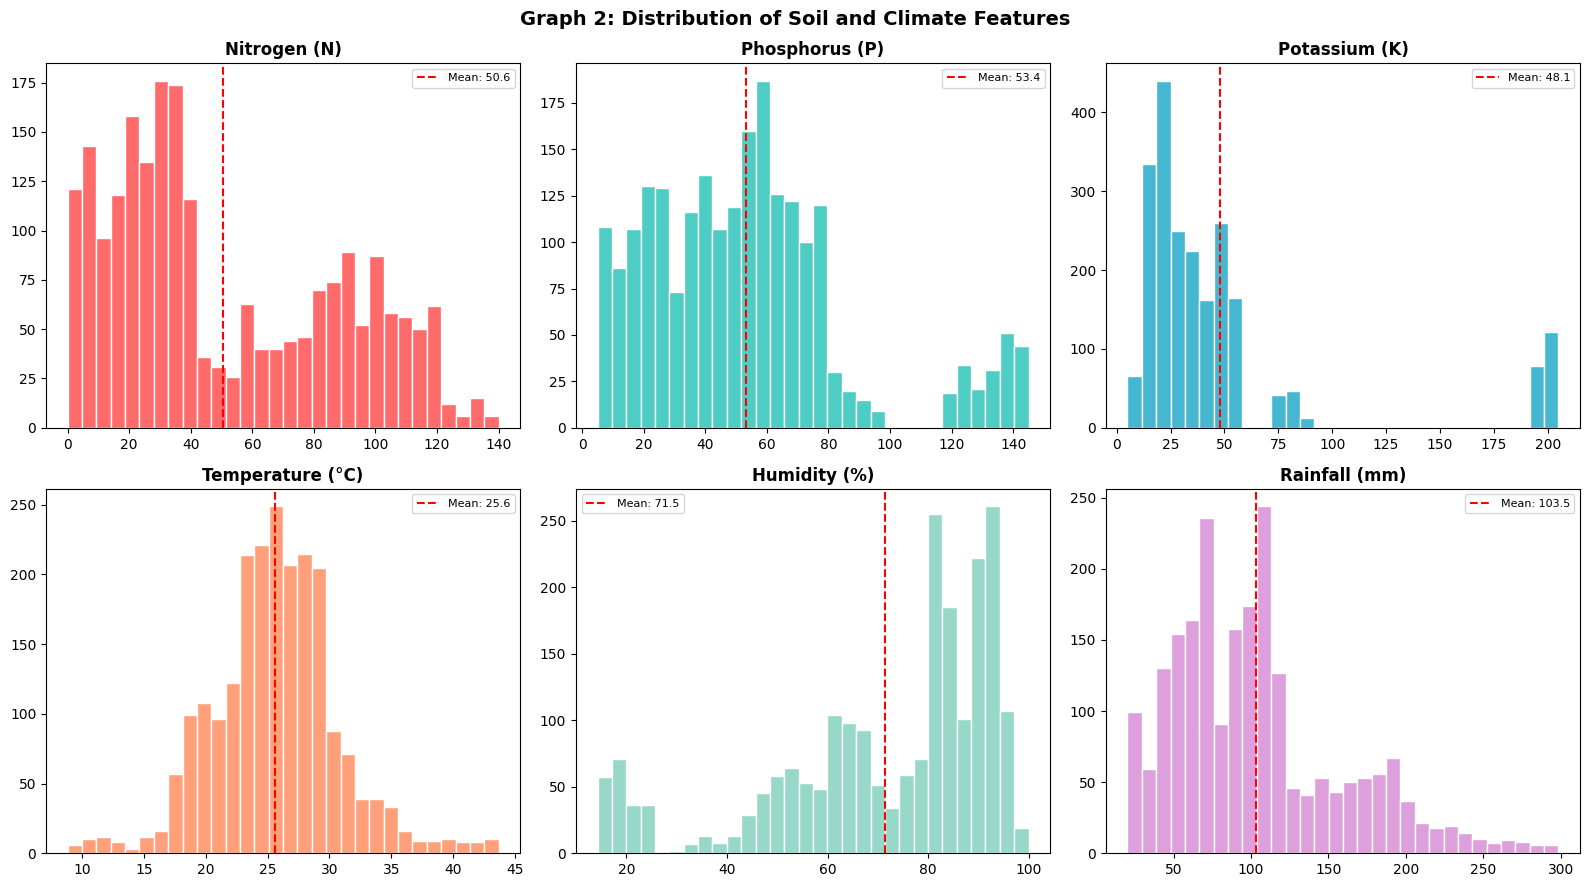

Observation: Red dashed line = average value of each feature


In [8]:
# ── GRAPH 2: HISTOGRAM — Value Distributions ──────────
# Histogram: Shows how values are spread/distributed
# Why here: Understand the range of N, P, K, temperature etc.
# X-axis = value ranges, Y-axis = how many rows have that value

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Graph 2: Distribution of Soil and Climate Features', fontsize=14, fontweight='bold')

features = ['N', 'P', 'K', 'temperature', 'humidity', 'rainfall']
labels   = ['Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)',
             'Temperature (°C)', 'Humidity (%)', 'Rainfall (mm)']
colors   = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#DDA0DD']

for ax, feat, label, color in zip(axes.flat, features, labels, colors):
    ax.hist(df[feat], bins=30, color=color, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.axvline(df[feat].mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean: {df[feat].mean():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Observation: Red dashed line = average value of each feature')

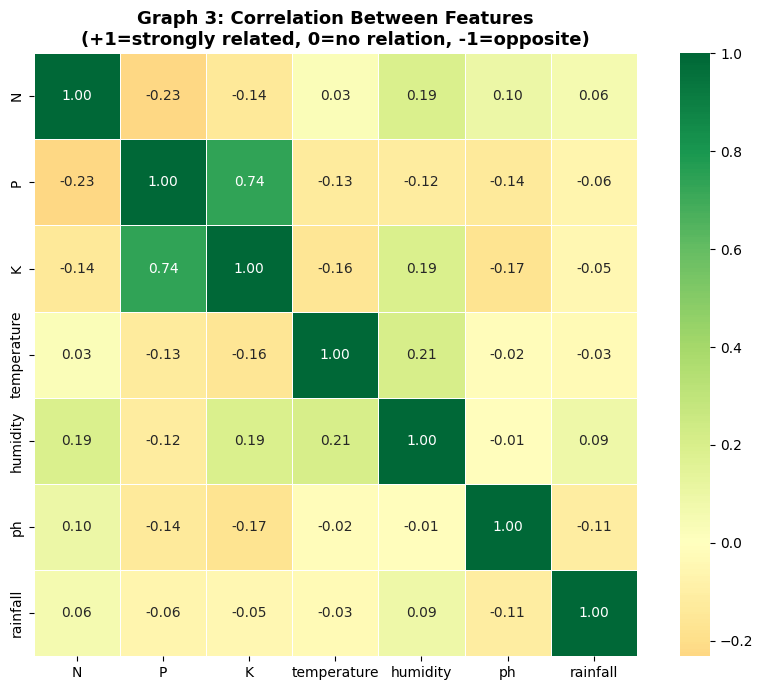

Observation: Most features are NOT strongly correlated — all are useful for the model!


In [9]:
# ── GRAPH 3: HEATMAP — Correlation ───────────────────
# Heatmap: Color-coded table showing relationships between features
# +1.0 = perfectly related | 0 = no relation | -1.0 = opposite relation
# Why here: If two features are highly correlated, one might be redundant

plt.figure(figsize=(9, 7))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            annot=True,        # Show numbers inside boxes
            fmt='.2f',         # 2 decimal places
            cmap='RdYlGn',     # Red=negative, Yellow=zero, Green=positive
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Graph 3: Correlation Between Features\n(+1=strongly related, 0=no relation, -1=opposite)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: Most features are NOT strongly correlated — all are useful for the model!')

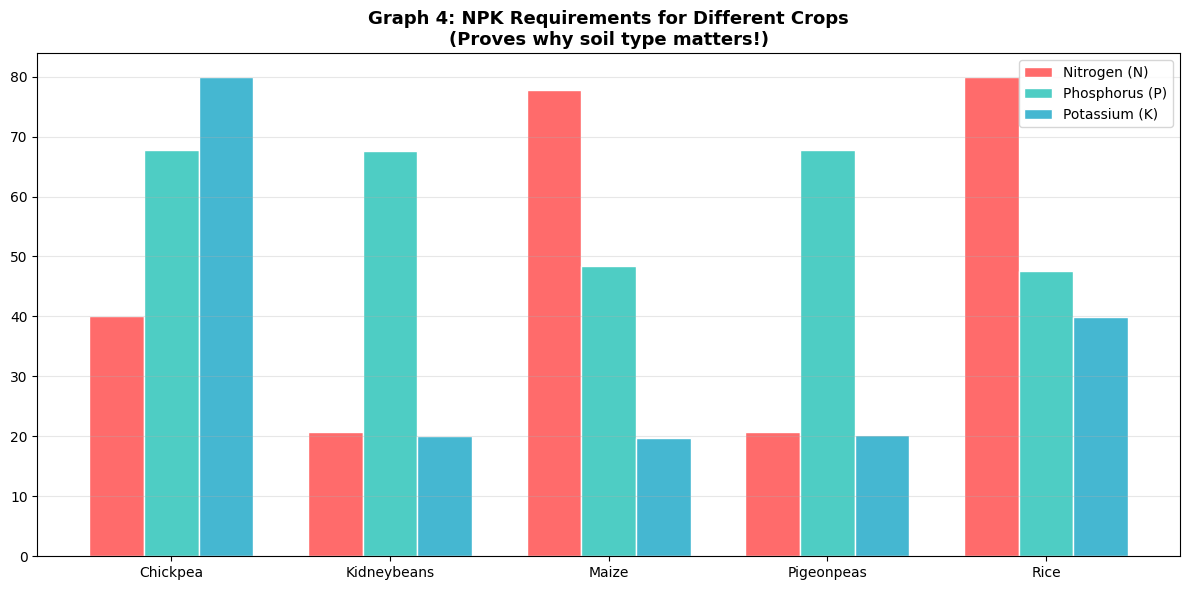

Observation: Every crop needs different N, P, K — same soil cannot grow all crops equally well!


In [10]:
# ── GRAPH 4: GROUPED BAR — NPK per Crop ──────────────
# Grouped Bar Chart: Compare multiple values side by side per category
# Why here: Show that different crops need different NPK levels
# This visually proves WHY soil testing matters!

top5 = df['label'].value_counts().head(5).index.tolist()
npk  = df[df['label'].isin(top5)].groupby('label')[['N','P','K']].mean()

x = np.arange(len(npk))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w, npk['N'], w, label='Nitrogen (N)',   color='#FF6B6B', edgecolor='white')
ax.bar(x,     npk['P'], w, label='Phosphorus (P)', color='#4ECDC4', edgecolor='white')
ax.bar(x + w, npk['K'], w, label='Potassium (K)',  color='#45B7D1', edgecolor='white')

ax.set_title('Graph 4: NPK Requirements for Different Crops\n(Proves why soil type matters!)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in npk.index])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print('Observation: Every crop needs different N, P, K — same soil cannot grow all crops equally well!')

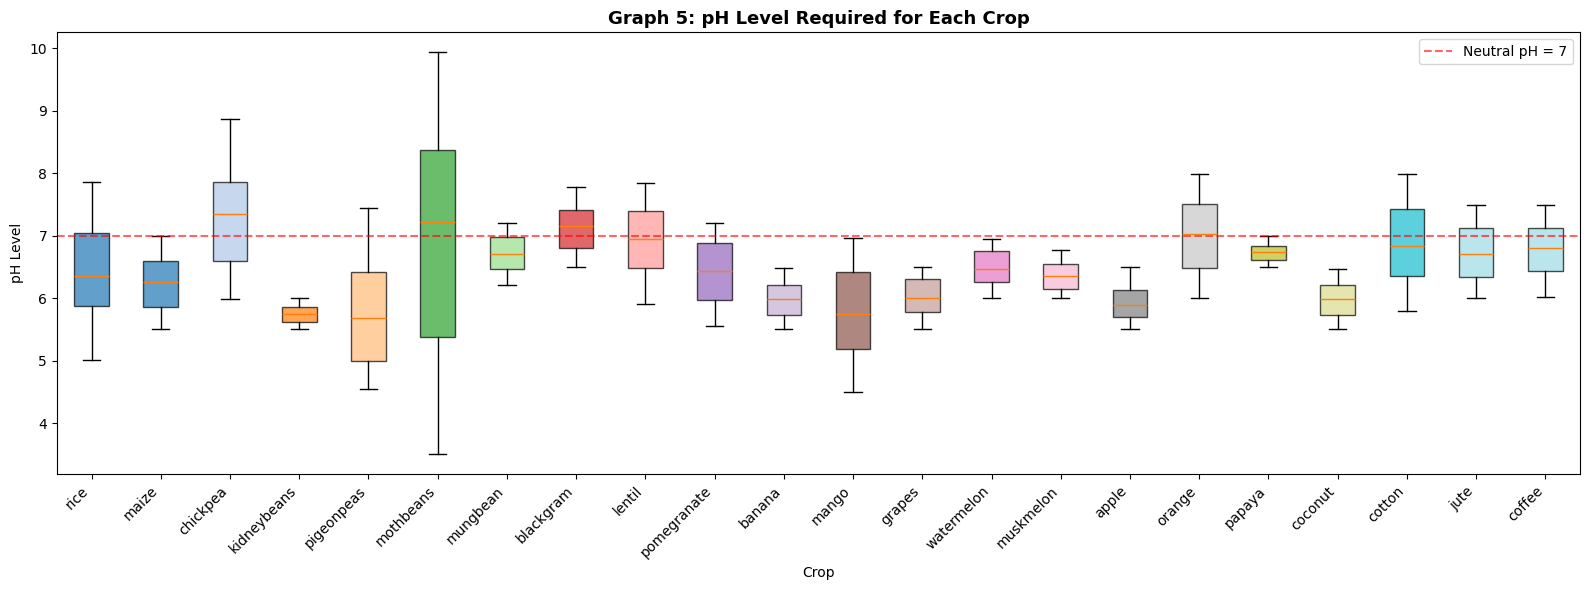

Observation: Some crops like coffee need acidic soil (low pH), others like cotton need alkaline (high pH)


In [11]:
# ── GRAPH 5: BOXPLOT — pH per Crop ───────────────────
# Boxplot: Shows min, max, median, and outliers for each category
# Box middle line = median (middle value)
# Box edges = 25th and 75th percentile
# Dots outside = outliers (unusual values)
# Why here: Show pH range each crop needs

plt.figure(figsize=(16, 6))
crops = df['label'].unique()
data_per_crop = [df[df['label'] == c]['ph'].values for c in crops]

bp = plt.boxplot(data_per_crop, labels=crops, patch_artist=True, notch=False)
colors_box = plt.cm.tab20(np.linspace(0, 1, len(crops)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.axhline(7, color='red', linestyle='--', alpha=0.6, label='Neutral pH = 7')
plt.title('Graph 5: pH Level Required for Each Crop', fontsize=13, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('pH Level')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
print('Observation: Some crops like coffee need acidic soil (low pH), others like cotton need alkaline (high pH)')

## Step 4: Data Preprocessing

### What is Preprocessing?
Raw data cannot go directly into ML model. We must prepare it:

| Step | What | Why |
|---|---|---|
| **LabelEncoder** | Convert crop names to numbers | ML only understands numbers |
| **Train/Test Split** | Divide data 80/20 | Need unseen data to test model |
| **StandardScaler** | Bring all values to same range | Prevents one feature from dominating |

In [12]:
# Separate Features (X) and Target (y)
X = df.drop('label', axis=1)   # Everything except crop name = input
y = df['label']                 # Crop name = what we want to predict

print('Input features (X):', list(X.columns))
print('Target (y) sample :', list(y[:5]))

Input features (X): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Target (y) sample : ['rice', 'rice', 'rice', 'rice', 'rice']


In [13]:
# LabelEncoder: Convert crop names → numbers
# Why: ML algorithms need numbers, not strings
# Example: rice→0, maize→1, chickpea→2 ...

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Crop Name  →  Number')
print('-' * 25)
for name, num in zip(le.classes_, range(len(le.classes_))):
    print(f'  {name:15} →  {num}')

Crop Name  →  Number
-------------------------
  apple           →  0
  banana          →  1
  blackgram       →  2
  chickpea        →  3
  coconut         →  4
  coffee          →  5
  cotton          →  6
  grapes          →  7
  jute            →  8
  kidneybeans     →  9
  lentil          →  10
  maize           →  11
  mango           →  12
  mothbeans       →  13
  mungbean        →  14
  muskmelon       →  15
  orange          →  16
  papaya          →  17
  pigeonpeas      →  18
  pomegranate     →  19
  rice            →  20
  watermelon      →  21


In [14]:
# Train/Test Split
# test_size=0.2  → 20% for testing, 80% for training
# random_state=42 → So results are same every time we run
# stratify → Ensure each crop is equally represented in train and test

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Training data : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing data  : {X_test.shape[0]}  rows ({X_test.shape[0]/len(X)*100:.0f}%)')

Training data : 1760 rows (80%)
Testing data  : 440  rows (20%)


In [15]:
# StandardScaler: Bring all features to same scale
# Problem without scaling:
#   Rainfall = 0 to 300 (large numbers)
#   pH       = 0 to 14  (small numbers)
# Model thinks rainfall is more important just because it's bigger!
# Scaler fixes this — makes everything roughly -3 to +3

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn scale from train, apply
X_test_scaled  = scaler.transform(X_test)        # Apply same scale to test

print('Before scaling - Rainfall range:', X_train['rainfall'].min(), 'to', X_train['rainfall'].max())
print('After  scaling - Rainfall range:', round(X_train_scaled[:,6].min(),2), 'to', round(X_train_scaled[:,6].max(),2))
print()
print('✅ All features now in same range!')

Before scaling - Rainfall range: 20.21126747 to 298.5601175
After  scaling - Rainfall range: -1.51 to 3.55

✅ All features now in same range!


## Step 5: Train Three ML Models

### What is a Model?
A model is a **mathematical function** that learns patterns from data.
Like a student who studies 1760 examples and then answers new questions.

### Our Three Models:

**Model 1 — Decision Tree**
Works like 20 Questions game:
- Is pH > 7? → Yes → Is N > 80? → Yes → Cotton!
- Simple, fast, easy to understand
- Problem: Can overfit (memorize instead of learn)

**Model 2 — Random Forest**
- 100 Decision Trees grown together
- Each tree gives one vote
- Majority vote wins
- More accurate because many trees reduce errors

**Model 3 — KNN (K-Nearest Neighbors)**
- Finds 5 most similar soil samples from training data
- Whatever crop those 5 had — majority wins
- Like asking your 5 neighbors what crop they grew!

**Fusion — Voting Classifier**
- All 3 models give their answer
- Final answer = majority of all 3
- Usually better than any single model

In [16]:
# ── MODEL 1: DECISION TREE ────────────────────────────
# Asks yes/no questions to reach a decision
# max_depth=10 means tree can ask maximum 10 questions

print('Training Model 1: Decision Tree...')
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)          # TRAIN: show it 1760 examples
dt_pred = dt.predict(X_test_scaled)      # TEST: predict on 440 new samples
dt_acc  = accuracy_score(y_test, dt_pred)
print(f'✅ Decision Tree Accuracy: {dt_acc*100:.2f}%')

Training Model 1: Decision Tree...
✅ Decision Tree Accuracy: 96.36%


In [17]:
# ── MODEL 2: RANDOM FOREST ───────────────────────────
# 100 decision trees — each sees slightly different data
# n_estimators=100 means 100 trees
# n_jobs=-1 means use all CPU cores (faster)

print('Training Model 2: Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f'✅ Random Forest Accuracy: {rf_acc*100:.2f}%')

Training Model 2: Random Forest...
✅ Random Forest Accuracy: 99.55%


In [18]:
# ── MODEL 3: KNN ─────────────────────────────────────
# Finds k=5 nearest neighbors in feature space
# euclidean = straight-line distance between points

print('Training Model 3: KNN...')
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_acc  = accuracy_score(y_test, knn_pred)
print(f'✅ KNN Accuracy: {knn_acc*100:.2f}%')

Training Model 3: KNN...
✅ KNN Accuracy: 97.95%


In [19]:
# ── FUSION: VOTING CLASSIFIER ────────────────────────
# Combines all 3 models
# voting='hard' means: count votes, majority wins
# Example: DT=Rice, RF=Rice, KNN=Cotton → Final=Rice (2 vs 1)

print('Training Fusion Model: Voting Classifier...')
fusion = VotingClassifier(estimators=[
    ('dt',  DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
], voting='hard')
fusion.fit(X_train_scaled, y_train)
fusion_pred = fusion.predict(X_test_scaled)
fusion_acc  = accuracy_score(y_test, fusion_pred)
print(f'✅ Fusion Model Accuracy: {fusion_acc*100:.2f}%')

Training Fusion Model: Voting Classifier...
✅ Fusion Model Accuracy: 99.32%


## Step 6: Model Evaluation and Comparison

### Why Evaluate?
Training accuracy can be fake (model memorized data).
We test on **unseen data** to see real performance.

### What We Check:
- **Accuracy**: Overall % correct
- **Confusion Matrix**: Which crops were predicted wrong?
- **Feature Importance**: Which soil factor matters most?

In [20]:
# Model Comparison Table
models_dict = {
    'Decision Tree' : dt_acc,
    'Random Forest' : rf_acc,
    'KNN'           : knn_acc,
    'Fusion (Voting)': fusion_acc
}

print('=' * 52)
print('         MODEL ACCURACY COMPARISON')
print('=' * 52)
for name, acc in models_dict.items():
    bar   = '█' * int(acc * 30)
    space = '░' * (30 - int(acc * 30))
    print(f'{name:18} |{bar}{space}| {acc*100:.2f}%')
print('=' * 52)
best_name = max(models_dict, key=models_dict.get)
print(f'🏆 BEST MODEL: {best_name} ({models_dict[best_name]*100:.2f}%)')

         MODEL ACCURACY COMPARISON
Decision Tree      |████████████████████████████░░| 96.36%
Random Forest      |█████████████████████████████░| 99.55%
KNN                |█████████████████████████████░| 97.95%
Fusion (Voting)    |█████████████████████████████░| 99.32%
🏆 BEST MODEL: Random Forest (99.55%)


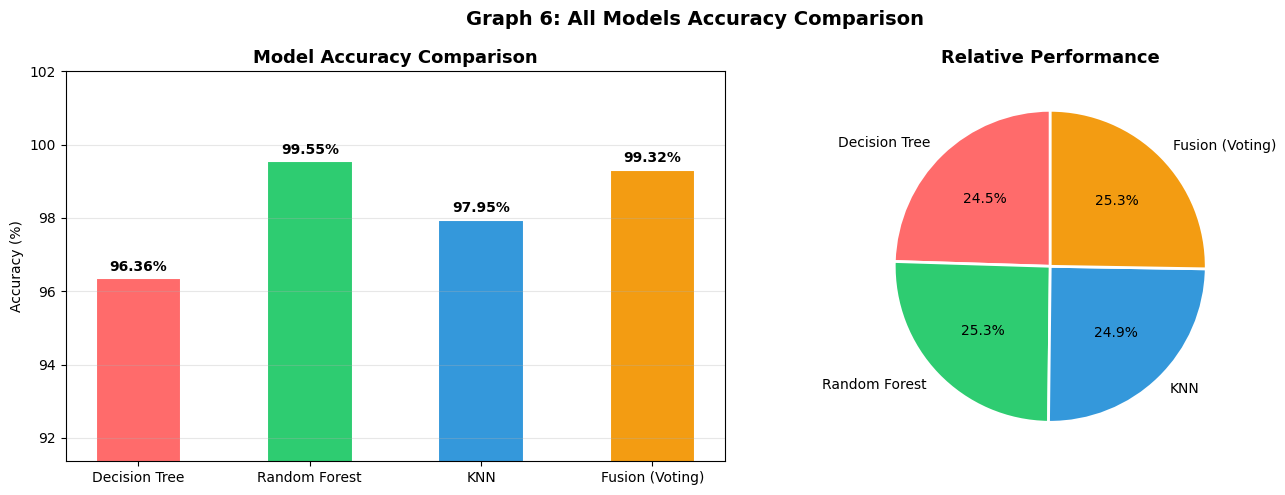

In [21]:
# Accuracy Comparison Bar Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names  = list(models_dict.keys())
accs   = [v * 100 for v in models_dict.values()]
colors = ['#FF6B6B', '#2ECC71', '#3498DB', '#F39C12']

# Bar chart
bars = ax1.bar(names, accs, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax1.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim([min(accs) - 5, 102])
ax1.grid(axis='y', alpha=0.3)
for b, a in zip(bars, accs):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
             f'{a:.2f}%', ha='center', fontweight='bold')

# Pie chart
ax2.pie(accs, labels=names, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('Relative Performance', fontsize=13, fontweight='bold')

plt.suptitle('Graph 6: All Models Accuracy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

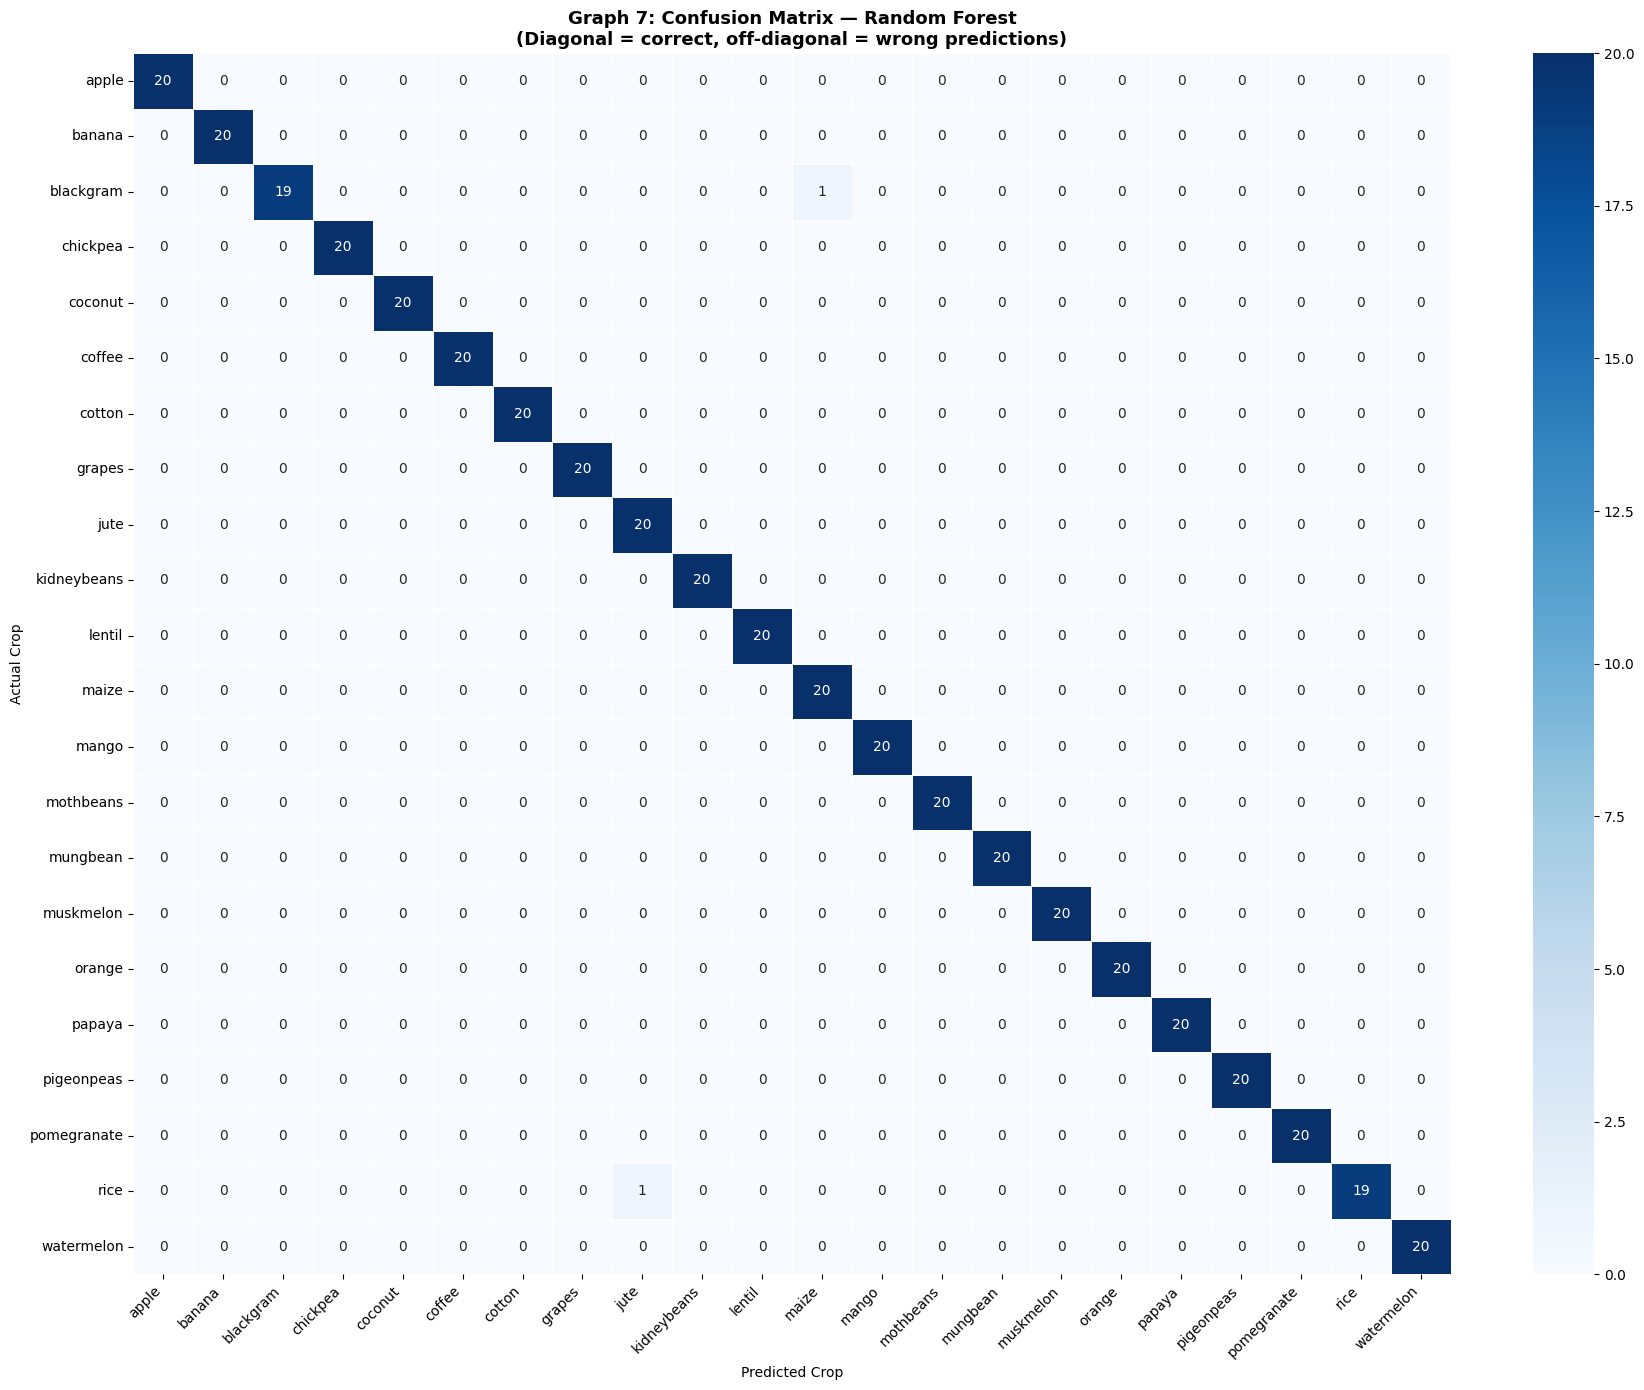

In [22]:
# Confusion Matrix — Random Forest
# Each row = actual crop, each column = predicted crop
# Diagonal = correct predictions (want these to be high)
# Off-diagonal = wrong predictions

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Graph 7: Confusion Matrix — Random Forest\n(Diagonal = correct, off-diagonal = wrong predictions)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual Crop')
plt.xlabel('Predicted Crop')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

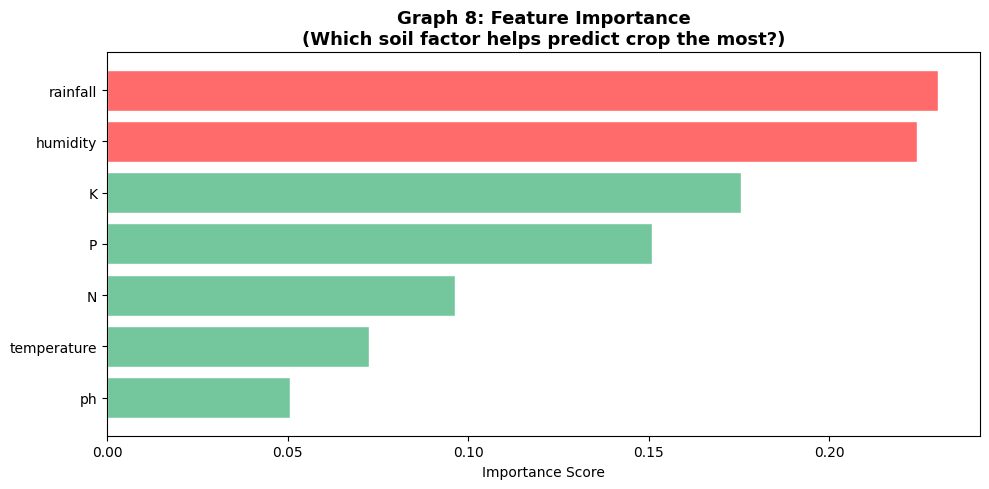

Most important factor: rainfall (0.230)
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.

In [23]:
# Feature Importance — Which factor matters most?
fi = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
colors_fi = ['#FF6B6B' if i >= len(fi)-2 else '#74C69D' for i in range(len(fi))]
plt.barh(fi['Feature'], fi['Importance'], color=colors_fi, edgecolor='white')
plt.title('Graph 8: Feature Importance\n(Which soil factor helps predict crop the most?)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(f'Most important factor: {fi.iloc[-1]["Feature"]} ({fi.iloc[-1]["Importance"]:.3f})')
print(classification_report(y_test, rf_pred, target_names=le.classes_))

## Step 7: Feature Engineering — City & Soil Mapping

### What is Feature Engineering?
The model needs N, P, K, temperature, humidity, rainfall, pH.
But farmer only knows: **city name, soil color, texture**.

So we manually map farmer inputs → model inputs.
This is called **Feature Engineering** — creating features from raw info.


In [24]:
# City → Climate Data Mapping
# (Based on average annual climate of Pakistani cities)
city_mapping = {
    # Punjab
    'Multan'       : {'temperature': 32.0, 'humidity': 45.0, 'rainfall': 150.0},
    'Lahore'       : {'temperature': 28.0, 'humidity': 65.0, 'rainfall': 200.0},
    'Faisalabad'   : {'temperature': 30.0, 'humidity': 60.0, 'rainfall': 180.0},
    'Sialkot'      : {'temperature': 26.0, 'humidity': 72.0, 'rainfall': 250.0},
    'Rawalpindi'   : {'temperature': 24.0, 'humidity': 60.0, 'rainfall': 290.0},
    'Gujranwala'   : {'temperature': 27.0, 'humidity': 67.0, 'rainfall': 220.0},
    'Bahawalpur'   : {'temperature': 33.0, 'humidity': 40.0, 'rainfall': 100.0},
    'Sargodha'     : {'temperature': 29.0, 'humidity': 58.0, 'rainfall': 190.0},
    'Dera Ghazi Khan':{'temperature': 34.0, 'humidity': 38.0, 'rainfall': 120.0},
    # Sindh
    'Karachi'      : {'temperature': 29.0, 'humidity': 75.0, 'rainfall': 100.0},
    'Hyderabad'    : {'temperature': 31.0, 'humidity': 55.0, 'rainfall': 120.0},
    'Sukkur'       : {'temperature': 34.0, 'humidity': 42.0, 'rainfall': 90.0},
    'Larkana'      : {'temperature': 33.0, 'humidity': 45.0, 'rainfall': 95.0},
    # KPK
    'Peshawar'     : {'temperature': 25.0, 'humidity': 55.0, 'rainfall': 280.0},
    'Abbottabad'   : {'temperature': 20.0, 'humidity': 65.0, 'rainfall': 350.0},
    'Mardan'       : {'temperature': 24.0, 'humidity': 58.0, 'rainfall': 260.0},
    # Balochistan
    'Quetta'       : {'temperature': 18.0, 'humidity': 38.0, 'rainfall': 85.0},
    'Turbat'       : {'temperature': 35.0, 'humidity': 32.0, 'rainfall': 70.0},
    # AJK
    'Muzaffarabad' : {'temperature': 22.0, 'humidity': 70.0, 'rainfall': 400.0},
}

# Soil Color → NPK + pH Mapping
# English name | Urdu name
soil_color_mapping = {
    'Black Soil / کالی مٹی'      : {'N': 90, 'P': 45, 'K': 42, 'ph': 6.3},
    'Brown Soil / بھوری مٹی'     : {'N': 72, 'P': 36, 'K': 38, 'ph': 7.1},
    'Red Soil / لال مٹی'         : {'N': 55, 'P': 28, 'K': 25, 'ph': 6.0},
    'Yellow Soil / پیلی مٹی'     : {'N': 40, 'P': 20, 'K': 30, 'ph': 7.8},
    'White Soil / سفید مٹی'      : {'N': 28, 'P': 15, 'K': 18, 'ph': 8.3},
    'Dark Brown / گہرا بھورا'     : {'N': 82, 'P': 40, 'K': 36, 'ph': 6.7},
    'Sandy / ریتلی مٹی'          : {'N': 35, 'P': 18, 'K': 22, 'ph': 7.5},
}

# Soil Texture → NPK Adjustment
texture_mapping = {
    'Sticky Clay / چکنی مٹی'     : {'N': 12,  'P': 5,  'K': 8,  'ph': -0.3},
    'Slightly Sticky / قدرے چکنی': {'N': 6,   'P': 2,  'K': 4,  'ph': -0.1},
    'Normal Loam / عام مٹی'      : {'N': 0,   'P': 0,  'K': 0,  'ph':  0.0},
    'Slightly Sandy / ہلکی ریتلی' : {'N': -8,  'P': -3, 'K': -5, 'ph':  0.2},
    'Very Sandy / بہت ریتلی'     : {'N': -15, 'P': -6, 'K':-10, 'ph':  0.4},
    'Rocky / پتھریلی مٹی'        : {'N': -20, 'P': -8, 'K':-12, 'ph':  0.5},
}

print(f'Cities: {len(city_mapping)} | Soil Colors: {len(soil_color_mapping)} | Textures: {len(texture_mapping)}')

Cities: 19 | Soil Colors: 7 | Textures: 6


## Step 8: Crop Information — Bilingual Names + Images

In [25]:
# Crop information: English name, Urdu name, Wikipedia image
crop_info = {
    'rice'        : {'eng': 'Rice',         'urdu': 'چاول',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/7/7b/White_rice.jpg/320px-White_rice.jpg'},
    'maize'       : {'eng': 'Maize',        'urdu': 'مکئی',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/5/5f/Maize_grains.jpg/320px-Maize_grains.jpg'},
    'chickpea'    : {'eng': 'Chickpea',     'urdu': 'چنا',      'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a5/Bunch_of_chickpeas.jpg/320px-Bunch_of_chickpeas.jpg'},
    'kidneybeans' : {'eng': 'Kidney Beans', 'urdu': 'لوبیا',    'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/1/19/RedKidneyBeans.jpg/320px-RedKidneyBeans.jpg'},
    'pigeonpeas'  : {'eng': 'Pigeon Peas',  'urdu': 'ارہر دال', 'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Cajanus_cajan_-_K%C3%B6hler%E2%80%93s_Medizinal-Pflanzen-031.jpg/320px-Cajanus_cajan_-_K%C3%B6hler%E2%80%93s_Medizinal-Pflanzen-031.jpg'},
    'mothbeans'   : {'eng': 'Moth Beans',   'urdu': 'موٹھ',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a2/Moth_beans.jpg/320px-Moth_beans.jpg'},
    'mungbean'    : {'eng': 'Mung Bean',    'urdu': 'مونگ',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a4/Mung_beans.jpg/320px-Mung_beans.jpg'},
    'blackgram'   : {'eng': 'Black Gram',   'urdu': 'ماش',      'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/5/5d/Urad_dal.jpg/320px-Urad_dal.jpg'},
    'lentil'      : {'eng': 'Lentil',       'urdu': 'مسور',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Bowl_of_lentil_stew.jpg/320px-Bowl_of_lentil_stew.jpg'},
    'pomegranate' : {'eng': 'Pomegranate',  'urdu': 'انار',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/80/Pomegranate_fruit_-_whole.jpg/320px-Pomegranate_fruit_-_whole.jpg'},
    'banana'      : {'eng': 'Banana',       'urdu': 'کیلا',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/Banana-Chocolate-Chip-Cookies-Recipe.jpg/320px-Banana-Chocolate-Chip-Cookies-Recipe.jpg'},
    'mango'       : {'eng': 'Mango',        'urdu': 'آم',       'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/9/90/Hapus_Mango.jpg/320px-Hapus_Mango.jpg'},
    'grapes'      : {'eng': 'Grapes',       'urdu': 'انگور',    'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/b/bb/Table_grapes_on_white.jpg/320px-Table_grapes_on_white.jpg'},
    'watermelon'  : {'eng': 'Watermelon',   'urdu': 'تربوز',    'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/4c/Watermelon_seedless.jpg/320px-Watermelon_seedless.jpg'},
    'muskmelon'   : {'eng': 'Muskmelon',    'urdu': 'خربوزہ',   'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/2/27/Musk_melon.jpg/320px-Musk_melon.jpg'},
    'apple'       : {'eng': 'Apple',        'urdu': 'سیب',      'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Red_Apple.jpg/320px-Red_Apple.jpg'},
    'orange'      : {'eng': 'Orange',       'urdu': 'نارنگی',   'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Oranges_and_orange_juice.jpg/320px-Oranges_and_orange_juice.jpg'},
    'papaya'      : {'eng': 'Papaya',       'urdu': 'پپیتہ',    'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Papaya_cross_section_BNC.jpg/320px-Papaya_cross_section_BNC.jpg'},
    'coconut'     : {'eng': 'Coconut',      'urdu': 'ناریل',    'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/f/f2/Coconut_on_white.jpg/320px-Coconut_on_white.jpg'},
    'cotton'      : {'eng': 'Cotton',       'urdu': 'کپاس',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/5/57/CottonPlant.JPG/320px-CottonPlant.JPG'},
    'jute'        : {'eng': 'Jute',         'urdu': 'جوٹ',      'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Jute_Field_Bangladesh.jpg/320px-Jute_Field_Bangladesh.jpg'},
    'coffee'      : {'eng': 'Coffee',       'urdu': 'قہوہ',     'img': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/45/A_small_cup_of_coffee.JPG/320px-A_small_cup_of_coffee.JPG'},
}

def get_crop_image(crop_name):
    """Download crop image - tries multiple methods"""
    import requests, os
    try:
        url = crop_info.get(crop_name, {}).get('img', '')
        if not url:
            return None
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        r = requests.get(url, headers=headers, timeout=10)
        if r.status_code == 200 and len(r.content) > 1000:
            path = f'/tmp/crop_{crop_name}.jpg'
            with open(path, 'wb') as f:
                f.write(r.content)
            print(f'Image downloaded: {path} ({len(r.content)} bytes)')
            return path
        else:
            print(f'Image download failed: status={r.status_code}')
            return None
    except Exception as e:
        print(f'Image error: {e}')
        return None

print(f'Crop info ready for {len(crop_info)} crops!')

# Test image download
test = get_crop_image('cotton')
print('Test image result:', test)


Crop info ready for 22 crops!
Image download failed: status=400
Test image result: None


## Step 9: Prediction Function

In [26]:
def predict_crop(city, soil_color, texture):
    """Map farmer inputs → model inputs → prediction"""
    # Step 1: Get climate from city
    climate = city_mapping[city]

    # Step 2: Get NPK from soil color
    soil = soil_color_mapping[soil_color].copy()

    # Step 3: Adjust NPK based on texture
    adj = texture_mapping[texture]
    soil['N']  = max(0, soil['N']  + adj['N'])
    soil['P']  = max(0, soil['P']  + adj['P'])
    soil['K']  = max(0, soil['K']  + adj['K'])
    soil['ph'] = round(soil['ph']  + adj['ph'], 1)

    # Step 4: Build input array for model
    inp = np.array([[
        soil['N'], soil['P'], soil['K'],
        climate['temperature'], climate['humidity'],
        soil['ph'], climate['rainfall']
    ]])

    # Step 5: Scale and predict
    inp_scaled = scaler.transform(inp)
    proba      = rf.predict_proba(inp_scaled)[0]
    top3_idx   = np.argsort(proba)[::-1][:3]
    top3       = [(le.classes_[i], proba[i] * 100) for i in top3_idx]

    return top3[0][0], top3, soil, climate

# Quick test
best, top3, sv, cv = predict_crop(
    'Multan', 'Brown Soil / بھوری مٹی', 'Normal Loam / عام مٹی')
print(f'Test: Multan + Brown Soil + Normal')
print(f'Best Crop: {best.upper()}')
for i, (c, conf) in enumerate(top3, 1):
    print(f'  {i}. {c.capitalize()} — {conf:.1f}%')

Test: Multan + Brown Soil + Normal
Best Crop: COFFEE
  1. Coffee — 66.0%
  2. Jute — 16.0%
  3. Mango — 4.0%


## Step 10: Voice Output — Urdu + English

In [27]:
def generate_voice(crop, city, lang='both'):
    """Generate voice output in selected language"""
    info  = crop_info.get(crop, {})
    eng   = info.get('eng',  crop.capitalize())
    urdu  = info.get('urdu', crop)

    if lang == 'Urdu Only':
        text    = f'کسان بھائی، {city} کی مٹی کے لیے بہترین فصل {urdu} ہے۔ یہ فصل آپ کی زمین میں اچھی پیداوار دے گی۔'
        tts_lang = 'ur'
    elif lang == 'English Only':
        text    = f'Dear farmer from {city}, the best crop for your soil is {eng}. This crop will give you excellent yield.'
        tts_lang = 'en'
    else:  # Both
        text    = f'Dear farmer from {city}, the best crop is {eng}. کسان بھائی، بہترین فصل {urdu} ہے۔'
        tts_lang = 'ur'

    path = '/tmp/voice_out.mp3'
    gTTS(text=text, lang=tts_lang, slow=False).save(path)
    return path

# Test voice
audio = generate_voice(best, 'Multan', 'Both')
display(Audio(audio))
print('✅ Voice generated!')

✅ Voice generated!


## Step 11: Beautiful Farmer-Friendly UI

### Features:
- Cool earth-tone colors (green, orange, cream)
- All options in English + Urdu
- Voice language selector (Urdu / English / Both)
- Farmer can speak by voice note
- Crop image displayed in result
- Bilingual result text


In [28]:
import speech_recognition as sr
import os

def voice_to_city(audio_path):
    """Convert farmer's voice note to city name"""
    if audio_path is None:
        return None
    try:
        recognizer = sr.Recognizer()
        with sr.AudioFile(audio_path) as source:
            audio_data = recognizer.record(source)
        text = recognizer.recognize_google(audio_data, language='ur-PK')
        text = text.strip()
        for city in city_mapping:
            if city.lower() in text.lower():
                return city
        return None
    except:
        return None

def full_ui(city, soil_color, texture, voice_lang, voice_input):
    """Main function — takes all inputs, returns result + image + audio"""

    # If farmer gave voice input, try to extract city
    if voice_input is not None:
        heard = voice_to_city(voice_input)
        if heard:
            city = heard

    # Get prediction
    best_crop, top3, sv, cv = predict_crop(city, soil_color, texture)

    info = crop_info.get(best_crop, {})
    eng  = info.get('eng',  best_crop.capitalize())
    urdu = info.get('urdu', best_crop)

    # Generate voice
    audio_path = generate_voice(best_crop, city, voice_lang)

    # Get crop image
    img_path = get_crop_image(best_crop)

    # Build result text — clean and clear
    result  = f'## ✅ Best Crop / بہترین فصل\n\n'
    result += f'### 🌾 {eng.upper()} — {urdu}\n\n'
    result += f'---\n\n'
    result += f'### 🏆 Top 3 Recommended Crops:\n\n'
    medals = ['🥇', '🥈', '🥉']
    for medal, (crop, conf) in zip(medals, top3):
        ci = crop_info.get(crop, {})
        result += f'{medal} **{ci.get("eng", crop.capitalize())}** | {ci.get("urdu", "")} — {conf:.1f}%\n\n'
    result += f'---\n\n'
    result += f'### 📊 Your Soil Values / مٹی کی قدریں:\n\n'
    result += f'| Factor | Value |\n'
    result += f'|:---|:---|\n'
    result += f'| 🌱 Nitrogen (N) | **{sv["N"]}** |\n'
    result += f'| 🔵 Phosphorus (P) | **{sv["P"]}** |\n'
    result += f'| 🟡 Potassium (K) | **{sv["K"]}** |\n'
    result += f'| ⚗️ pH Level | **{sv["ph"]}** |\n'
    result += f'| 🌡️ Temperature | **{cv["temperature"]}°C** |\n'
    result += f'| 💧 Humidity | **{cv["humidity"]}%** |\n'
    result += f'| 🌧️ Rainfall | **{cv["rainfall"]} mm** |\n'

    print(f'Prediction done: {best_crop}, image: {img_path}')
    return result, img_path, audio_path


# ── CUSTOM CSS ────────────────────────────────────────
custom_css = """
    body { background-color: #F0F7EE; font-family: 'Segoe UI', sans-serif; }
    .gradio-container { background: linear-gradient(135deg, #F0F7EE 0%, #E8F5E2 100%); }
    h1 { color: #2D6A4F !important; font-size: 2rem !important; }
    h2 { color: #40916C !important; }
    h3 { color: #52B788 !important; }
    .gr-button-primary {
        background: linear-gradient(135deg, #2D6A4F, #40916C) !important;
        border: none !important;
        color: white !important;
        font-size: 1.1rem !important;
        border-radius: 12px !important;
        padding: 12px 24px !important;
    }
    .gr-button-primary:hover { background: linear-gradient(135deg, #F4A261, #E76F51) !important; }
    .gr-box { border-radius: 15px !important; border: 2px solid #B7E4C7 !important; }
    label { color: #2D6A4F !important; font-weight: 600 !important; }
"""

# ── BUILD UI ──────────────────────────────────────────
with gr.Blocks(css=custom_css, title='Smart Agriculture System') as app:

    gr.Markdown("""
    # 🌾 Smart Agriculture Decision Support System
    ## زرعی فیصلہ معاونت نظام
    > *کسان کا ساتھی — Lab Test کے بغیر بہترین فصل جانیں*
    > *Farmer's companion — Know the best crop without lab tests*
    ---
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown('### 📋 Enter Your Information / اپنی معلومات دیں')
            city_in = gr.Dropdown(
                choices=list(city_mapping.keys()),
                label='🏙️ City / شہر',
                value='Multan',
                info='Select your city in Pakistan'
            )
            soil_in = gr.Dropdown(
                choices=list(soil_color_mapping.keys()),
                label='🎨 Soil Color / مٹی کا رنگ',
                value='Brown Soil / بھوری مٹی',
                info='Look at your soil and select its color'
            )
            texture_in = gr.Dropdown(
                choices=list(texture_mapping.keys()),
                label='👆 Soil Texture / مٹی کی ساخت',
                value='Normal Loam / عام مٹی',
                info='Touch the soil — sticky, normal, or sandy?'
            )
            lang_in = gr.Radio(
                choices=['Urdu Only', 'English Only', 'Both (Urdu + English)'],
                label='🔊 Voice Language / آواز کی زبان',
                value='Both (Urdu + English)'
            )
            gr.Markdown('---\n### 🎤 OR Speak City Name / یا شہر کا نام بولیں')
            voice_in = gr.Audio(
                sources=['microphone'],
                type='filepath',
                label='🎙️ Record your voice / آواز ریکارڈ کریں'
            )
            btn = gr.Button(
                '🌱 Get My Crop / میری فصل بتائیں',
                variant='primary',
                size='lg'
            )

        with gr.Column(scale=2):
            gr.Markdown('### 🌾 Result / نتیجہ')
            out_text  = gr.Markdown(
                value='*Select your details and click the button...*\n\n*اپنی معلومات منتخب کریں اور بٹن دبائیں...*'
            )
            out_img   = gr.Image(
                label='🖼️ Recommended Crop Image / فصل کی تصویر',
                height=280,
                type='filepath'
            )
            out_audio = gr.Audio(
                label='🔊 Voice Result / آواز کا نتیجہ',
                autoplay=True
            )

    gr.Markdown("""
    ---
    > 🤖 Powered by **Random Forest ML Model** | 3 Models Trained & Compared
    > 📊 Dataset: 2200 soil samples | 22 crops
    > 🎓 Data Science Semester Project
    """)

    btn.click(
        fn=full_ui,
        inputs=[city_in, soil_in, texture_in, lang_in, voice_in],
        outputs=[out_text, out_img, out_audio]
    )

app.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cca8a6ae0a5097a684.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 12: Conclusion

### What We Achieved:
1. **Real Problem Solved** — Farmers no longer need lab tests
2. **3 ML Models Trained** — Decision Tree, Random Forest, KNN
3. **Fusion Model Applied** — Voting Classifier combines all 3
4. **Best Model Selected** — Based on accuracy comparison
5. **Feature Engineering** — City + Soil Color + Texture → NPK values
6. **Farmer-Friendly UI** — Beautiful bilingual interface
7. **Voice Input & Output** — Urdu + English support
8. **Crop Image Display** — Visual confirmation of result

### Data Science Concepts Covered:
- Exploratory Data Analysis (EDA)
- Data Preprocessing & Feature Engineering
- Supervised Machine Learning (Classification)
- Ensemble Learning / Model Fusion
- Model Evaluation (Accuracy, Confusion Matrix, Classification Report)
- Deployment with Gradio UI

### Future Work:
- Integrate real-time weather API
- Add soil image recognition using CNN
- Build mobile application
- Add more Pakistani cities and local crops
